# Advanced Exploratory Data Analysis - Palmer Penguins Dataset

This notebook presents an advanced Exploratory Data Analysis (EDA) on the Palmer Penguins dataset. The objective is to transition this from a simple learning project to a comprehensive exploratory analysis by executing data cleaning, defining research questions, visualizing patterns, and drawing clear conclusions.

---

### Research Questions
1. **Which species is the heaviest?** We will compare body mass across Adelie, Chinstrap, and Gentoo species.
2. **Does sex affect body mass?** We will analyze differences in body mass between male and female penguins, both overall and within each species.
3. **Which measurements are most strongly related?** We will explore correlations between flipper length, bill length, bill depth, and body mass, keeping an eye out for interesting grouping effects.
4. **Are there outliers?** We will systematically inspect the dataset for any extreme observations that might skew our analysis.

---

### Analysis Structure
1. **Describe**: Initial data profiling, checking dimensions, column types, and missing values.
2. **Clean & Impute**: Explicitly handling the 19 missing values using structured imputation strategies.
3. **Explore & Visualize**: Conducting data exploration to answer our research questions with high-quality Seaborn charts.
4. **Conclusions & Recommendations**: Synthesizing the biological takeaways and discussing analytical considerations like Simpson's Paradox.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set styling
sns.set_theme(context='notebook', style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

## Phase 1: Describe
In this section, we load the raw dataset, profile the features, and identify missing values to understand the scope of required data cleaning.

In [2]:
# Load the raw dataset
df_raw = sns.load_dataset('penguins')

print(f"Dataset Shape: {df_raw.shape}")
print("\nData Fields and Types:")
print(df_raw.dtypes)

print("\nMissing Values per Column:")
print(df_raw.isna().sum())

print("\nTotal Missing Values:", df_raw.isna().sum().sum())

print("\nSummary Statistics for Numeric Columns:")
df_raw.describe()

Dataset Shape: (344, 7)

Data Fields and Types:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

Missing Values per Column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Total Missing Values: 19

Summary Statistics for Numeric Columns:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


## Phase 2: Data Cleaning and Imputation Strategy

The raw dataset contains 19 missing values in total:
* **Row-wise Null Scan**: There are two rows (indexes 3 and 339) where all size measurements (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) and the `sex` field are missing. These penguins have no biological metrics recorded.
  * *Strategy*: We will drop these 2 completely empty rows.
* **Categorical Missingness (Sex)**: The remaining 9 missing values are in the `sex` column, but these rows have complete body measurements. Dropping them would throw away valuable data.
  * *Strategy*: We will impute the missing `sex` values. Since sex is a major driver of size in penguins, we can impute the sex by comparing a penguin's body mass to the median body mass of its species. A penguin with body mass greater than the species median is imputed as `Male`, and `Female` otherwise.

In [3]:
df = df_raw.copy()

# Step 1: Drop rows where all size measurements are null
empty_rows = df[df['bill_length_mm'].isna() & df['body_mass_g'].isna()]
print(f"Dropping {len(empty_rows)} empty rows (indices: {list(empty_rows.index)})")
df = df.drop(empty_rows.index).reset_index(drop=True)

# Step 2: Impute missing sex values based on species-specific body mass medians
missing_sex_mask = df['sex'].isna()
print(f"Imputing missing sex for {missing_sex_mask.sum()} rows...")

for idx in df[missing_sex_mask].index:
    species = df.loc[idx, 'species']
    mass = df.loc[idx, 'body_mass_g']
    
    # Calculate median body mass of known sex penguins for this species
    species_data = df[(df['species'] == species) & df['sex'].notna()]
    median_mass = species_data['body_mass_g'].median()
    
    # Impute Male if heavier than median, Female otherwise
    imputed_sex = 'Male' if mass >= median_mass else 'Female'
    df.loc[idx, 'sex'] = imputed_sex
    print(f"Row {idx} ({species}, {mass}g) -> Imputed as {imputed_sex}")

print("\nPost-Cleaning Missing Values Count:")
print(df.isna().sum())

Dropping 2 empty rows (indices: [3, 339])
Imputing missing sex for 9 rows...
Row 7 (Adelie, 3475.0g) -> Imputed as Female
Row 8 (Adelie, 4250.0g) -> Imputed as Male
Row 9 (Adelie, 3300.0g) -> Imputed as Female
Row 10 (Adelie, 3700.0g) -> Imputed as Male
Row 46 (Adelie, 2975.0g) -> Imputed as Female
Row 245 (Gentoo, 4100.0g) -> Imputed as Female
Row 285 (Gentoo, 4650.0g) -> Imputed as Female
Row 323 (Gentoo, 4725.0g) -> Imputed as Female
Row 335 (Gentoo, 4875.0g) -> Imputed as Female

Post-Cleaning Missing Values Count:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


## Phase 3: Research Questions & Visualizations

Now that our data is clean, we will explore our four research questions.

/var/folders/56/hn3k7glj18bc1mbhpz18_bw80000gn/T/ipykernel_16515/566985753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='body_mass_g', palette='Set2', ax=ax)


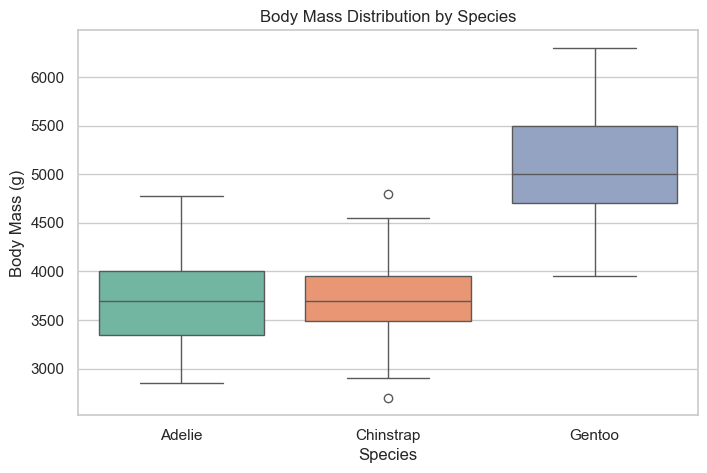

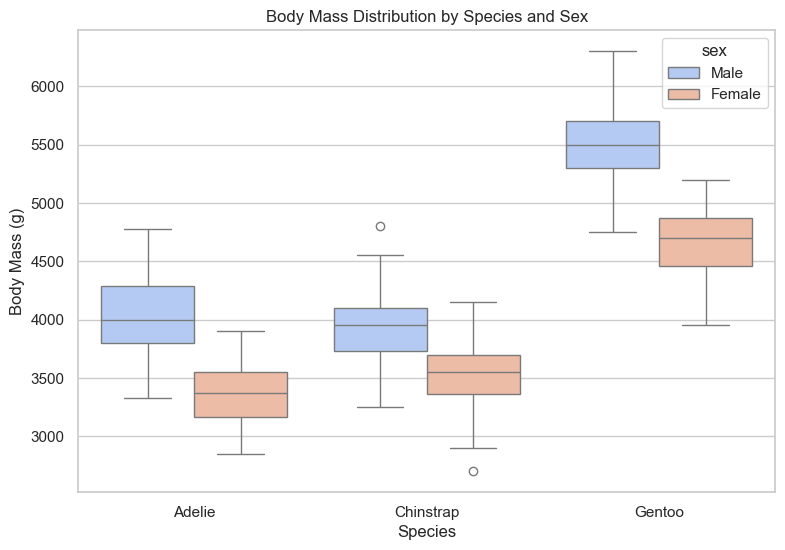

Correlation Matrix:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   

                   body_mass_g  
bill_length_mm        0.595110  
bill_depth_mm        -0.471916  
flipper_length_mm     0.871202  
body_mass_g           1.000000  


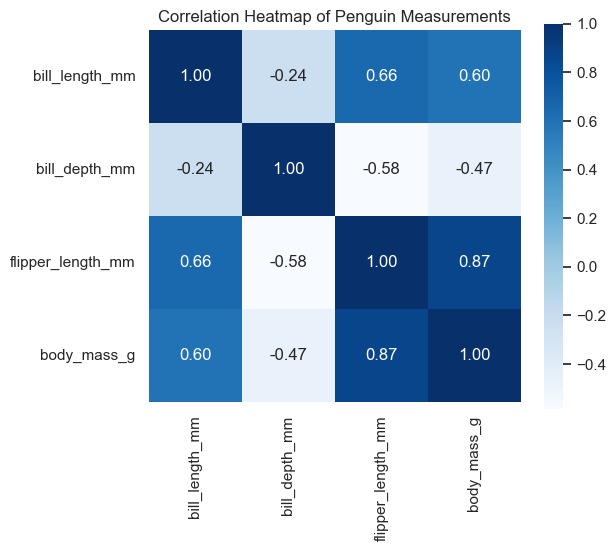

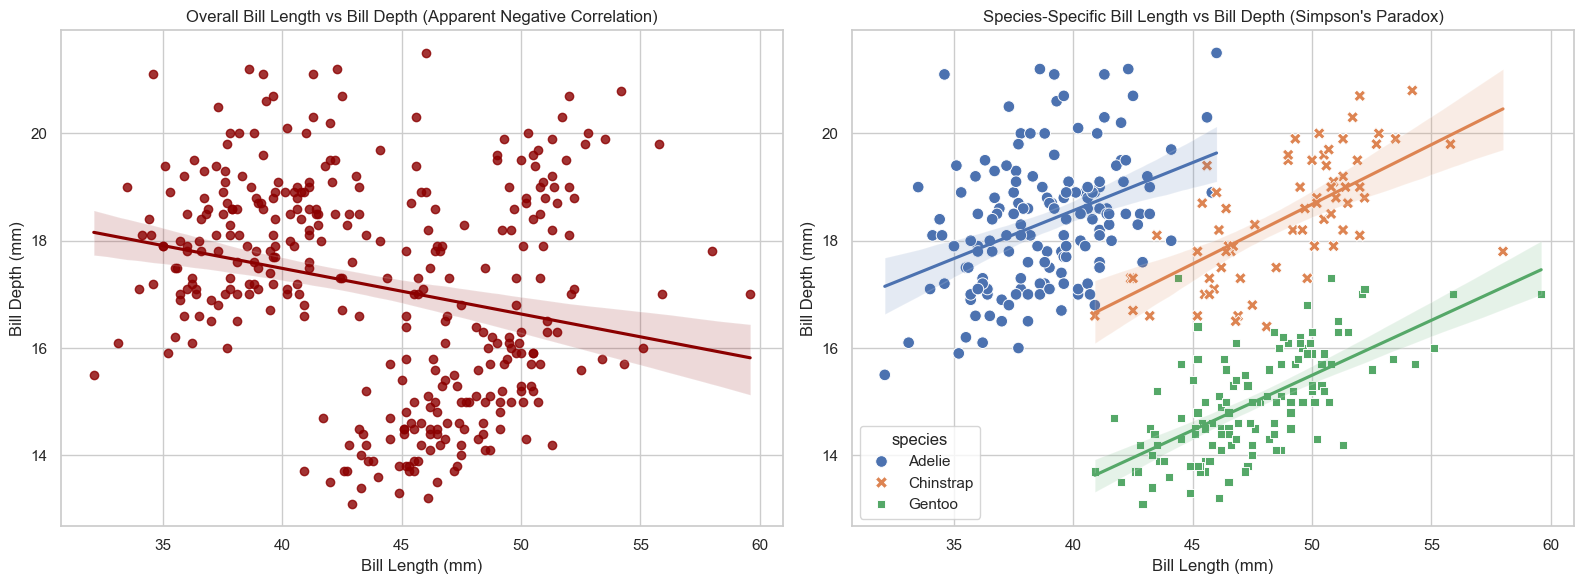

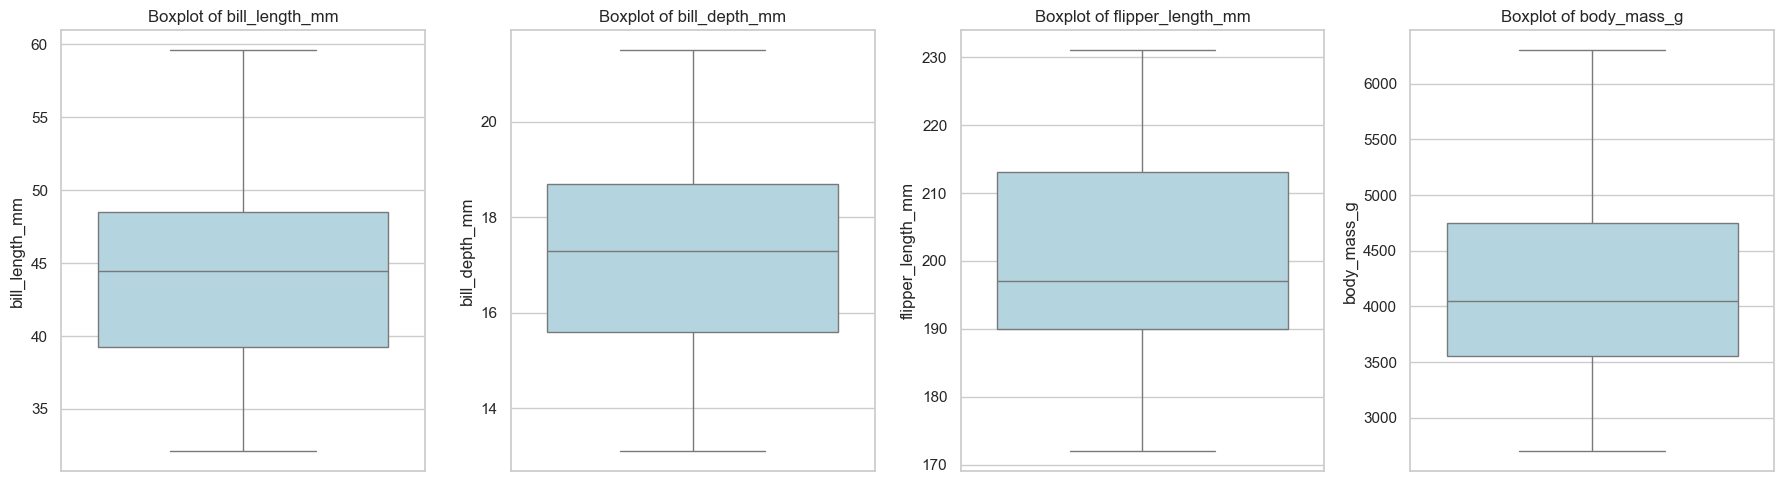

In [4]:
# Question 1: Which species is the heaviest?
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='body_mass_g', palette='Set2', ax=ax)
ax.set_title('Body Mass Distribution by Species')
ax.set_xlabel('Species')
ax.set_ylabel('Body Mass (g)')
plt.show()

# Question 2: Does sex affect body mass?
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x='species', y='body_mass_g', hue='sex', palette='coolwarm', ax=ax)
ax.set_title('Body Mass Distribution by Species and Sex')
ax.set_xlabel('Species')
ax.set_ylabel('Body Mass (g)')
plt.show()

# Question 3: Which measurements are most strongly related?
# Let's inspect the correlation matrix
corr_matrix = df.select_dtypes(include='number').corr()
print("Correlation Matrix:")
print(corr_matrix)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", square=True, ax=ax)
ax.set_title('Correlation Heatmap of Penguin Measurements')
plt.show()

# Scatter plot showing bill length vs bill depth (Overall vs Species-specific)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall regplot
sns.regplot(data=df, x='bill_length_mm', y='bill_depth_mm', ax=axes[0], color='darkred')
axes[0].set_title('Overall Bill Length vs Bill Depth (Apparent Negative Correlation)')
axes[0].set_xlabel('Bill Length (mm)')
axes[0].set_ylabel('Bill Depth (mm)')

# Species-specific scatter and regression lines
colors = sns.color_palette()
species_colors = {
    'Adelie': colors[0],
    'Chinstrap': colors[1],
    'Gentoo': colors[2]
}
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species', style='species', s=70, palette=species_colors, ax=axes[1])
for sp in df['species'].unique():
    sp_df = df[df['species'] == sp]
    sns.regplot(data=sp_df, x='bill_length_mm', y='bill_depth_mm', scatter=False, color=species_colors[sp], ax=axes[1])
axes[1].set_title("Species-Specific Bill Length vs Bill Depth (Simpson's Paradox)")
axes[1].set_xlabel('Bill Length (mm)')
axes[1].set_ylabel('Bill Depth (mm)')

plt.tight_layout()
plt.show()

# Question 4: Are there outliers?
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, y=col, color='lightblue', ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## Phase 4: Conclusions and Recommendations

### Key Findings
1. **Species is the Primary Size Driver**: Gentoo penguins are significantly heavier than both Adelie and Chinstrap penguins (with median weights around 5,000g vs 3,700g).
2. **Sex Determines Size Within Species**: Across all species, male penguins are consistently heavier than female penguins by roughly 10% to 15%.
3. **Simpson's Paradox (Grouping Effects)**:
   - If we calculate the overall correlation between bill length and bill depth, they appear negatively correlated (-0.23).
   - However, when we look *within each species*, they are strongly positively correlated (each species has an upward slope).
   - This occurs because Gentoo penguins have long, shallow bills, while Adelie penguins have short, deep bills. Failing to account for species grouping results in a misleading overall conclusion.
4. **No Significant Outliers**: The dataset is exceptionally clean and stable, with boxplots indicating no extreme outliers that would distort the statistics.

### Recommendations for Biological Data Analysis
* **Avoid Aggregated Correlations**: When working with ecological or biological datasets that contain multiple species or sub-populations, always verify trends within sub-groups. Grouping effects can mask the true biological relationships (as seen in Simpson's Paradox).
* **Control for Confounders**: When using body measurements to classify species or investigate environmental impacts, always control for both species and sex, as they are strong confounding variables for size and weight.